# Jaw Cutout and Masking (Side Profile)
This notebook isolates a person from the background and automatically applies a perfectly curated mask over the jaw area, designed specifically for pure side profile photos using an advanced geometric face parsing approach.

In [1]:
import cv2
import numpy as np
import torch
from PIL import Image
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

In [2]:
# Initialize Face Parser
print("Loading Face Parser model...")
processor = SegformerImageProcessor.from_pretrained("jonathandinu/face-parsing")
model = SegformerForSemanticSegmentation.from_pretrained("jonathandinu/face-parsing")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Model ready!")

Loading Face Parser model...


Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Model ready!


In [3]:
import tkinter as tk
from tkinter import filedialog

print("Opening file dialog... Please check your taskbar for the popup window.")

root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()

file_path = filedialog.askopenfilename(
    title="Select a Side Profile Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
)

root.destroy()

if file_path:
    print(f"Selected file: {file_path}")
    print("You can now run the next cell!")
else:
    print("No file selected.")


Opening file dialog... Please check your taskbar for the popup window.
Selected file: C:/Users/pratik01/Downloads/new-45-2.jpg
You can now run the next cell!


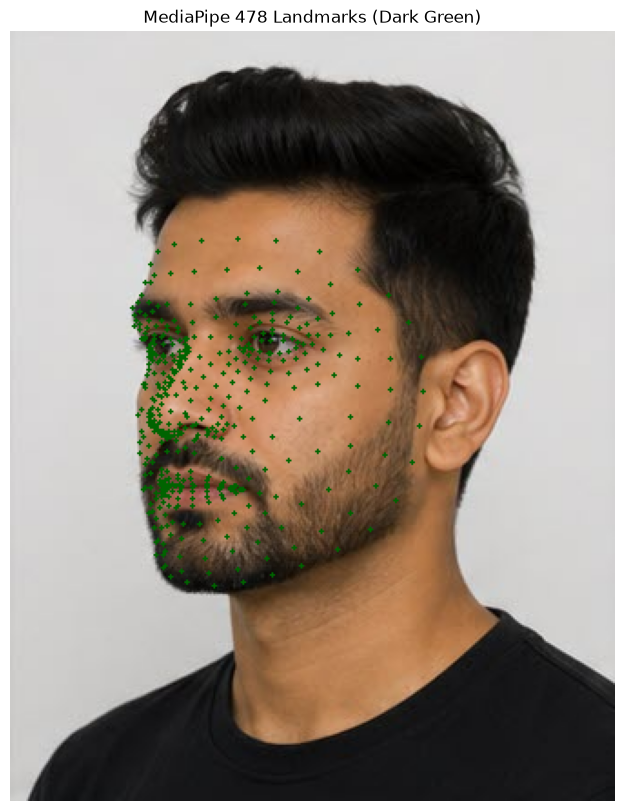

In [4]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt
import numpy as np

if 'file_path' in locals() and file_path:
    image = cv2.imread(file_path)
    if image is not None:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Initialize FaceLandmarker with modern Tasks API
        base_options = python.BaseOptions(model_asset_path="face_landmarker.task")
        options = vision.FaceLandmarkerOptions(base_options=base_options,
                                              output_face_blendshapes=False,
                                              output_facial_transformation_matrixes=False,
                                              num_faces=1)
        detector = vision.FaceLandmarker.create_from_options(options)
        
        # Process image
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
        detection_result = detector.detect(mp_image)
        
        # Draw landmarks with a darker green color
        annotated_image = image_rgb.copy()
        if detection_result.face_landmarks:
            for face_landmarks in detection_result.face_landmarks:
                for idx, landmark in enumerate(face_landmarks):
                    x = int(landmark.x * image.shape[1])
                    y = int(landmark.y * image.shape[0])
                    # Using a darker green: RGB(0, 100, 0)
                    cv2.circle(annotated_image, (x, y), 1, (0, 100, 0), -1)
                    
            plt.figure(figsize=(10, 10))
            plt.imshow(annotated_image)
            plt.axis('off')
            plt.title("MediaPipe 478 Landmarks (Dark Green)")
            plt.show()
        else:
            print("No face detected by MediaPipe in this image.")


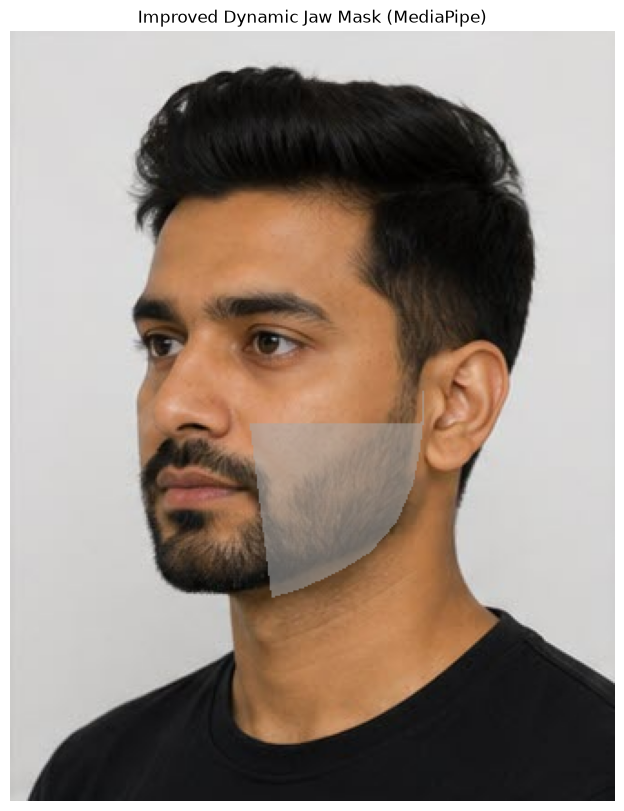

In [5]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt
import numpy as np

if 'file_path' in locals() and file_path:
    image = cv2.imread(file_path)
    if image is not None:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape
        
        # Initialize FaceLandmarker with modern Tasks API
        base_options = python.BaseOptions(model_asset_path="face_landmarker.task")
        options = vision.FaceLandmarkerOptions(base_options=base_options,
                                              output_face_blendshapes=False,
                                              output_facial_transformation_matrixes=False,
                                              num_faces=1)
        detector = vision.FaceLandmarker.create_from_options(options)
        
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
        detection_result = detector.detect(mp_image)
        
        if detection_result.face_landmarks:
            face_landmarks = detection_result.face_landmarks[0]
            
            # Determine face orientation using 3D Z-coordinates
            left_ear_z = face_landmarks[454].z
            right_ear_z = face_landmarks[234].z
            facing_left = right_ear_z < left_ear_z # Right ear is closer to camera
            
            if facing_left:
                jawline_indices = [234, 93, 132, 58, 172, 136, 150, 149, 176, 148, 152]
                ear_idx = 234
            else:
                jawline_indices = [454, 323, 361, 288, 397, 365, 379, 378, 400, 377, 152]
                ear_idx = 454
                
            nose_tip = face_landmarks[1]
            ear = face_landmarks[ear_idx]
            
            # Convert to pixel coordinates
            nose_x, nose_y = int(nose_tip.x * w), int(nose_tip.y * h)
            ear_x, ear_y = int(ear.x * w), int(ear.y * h)
            
            # Calculate the front boundary (e.g., 65% of the distance from ear to nose)
            # This perfectly mimics the cutoff point of the trapezoid mask
            if facing_left:
                front_x = int(ear_x + 0.65 * (nose_x - ear_x))
            else:
                front_x = int(ear_x - 0.65 * (ear_x - nose_x))
                
            # Build the dynamic polygon
            polygon_pts = []
            
            # 1. Start at top-back corner
            polygon_pts.append([ear_x, nose_y])
            
            # 2. Add top-front corner
            polygon_pts.append([front_x, nose_y])
            
            # 3. Trace the jawline backwards from the front cutoff point to the ear
            jawline_pts = []
            for idx in jawline_indices:
                pt_x = int(face_landmarks[idx].x * w)
                pt_y = int(face_landmarks[idx].y * h)
                
                # Push the jawline down slightly to account for the beard hanging below the jawbone
                # 3% of the image height is a good approximation for beard thickness
                pt_y += int(h * 0.03) 
                
                # Only include points that are behind the front cutoff line
                if (facing_left and pt_x <= front_x) or (not facing_left and pt_x >= front_x):
                    jawline_pts.append([pt_x, pt_y])
            
            # We need to reverse the jawline points so they connect cleanly from front to back
            jawline_pts = jawline_pts[::-1]
            polygon_pts.extend(jawline_pts)
            
            # 4. Close the polygon at the ear
            polygon_pts.append([ear_x, ear_y])
            
            polygon_pts = np.array(polygon_pts, np.int32)
            
            # Create a mask for the polygon
            poly_mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillPoly(poly_mask, [polygon_pts], 1)
            
            # Apply the semi-transparent gray overlay
            overlay = image_rgb.copy()
            overlay[poly_mask == 1] = [170, 170, 170]
            
            alpha = 0.55
            final_image = cv2.addWeighted(overlay, alpha, image_rgb, 1 - alpha, 0)
            
            plt.figure(figsize=(10, 10))
            plt.imshow(final_image)
            plt.axis('off')
            plt.title("Improved Dynamic Jaw Mask (MediaPipe)")
            plt.show()
        else:
            print("No face detected by MediaPipe. Please ensure it's a 45-degree or frontal image!")


# Your jaw shape **[front]**
The **frontal jaw angle**, measured from the **Gonion** to the **Menton**, determines how **inclined** or **flat** your lower third appears.

Opening file dialog for FRONT-FACING image... Please check your taskbar.
✅ Selected: C:/Users/pratik01/Downloads/images (1).jpeg


C:\Users\pratik01\AppData\Local\Temp\ipykernel_10220\2042182918.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


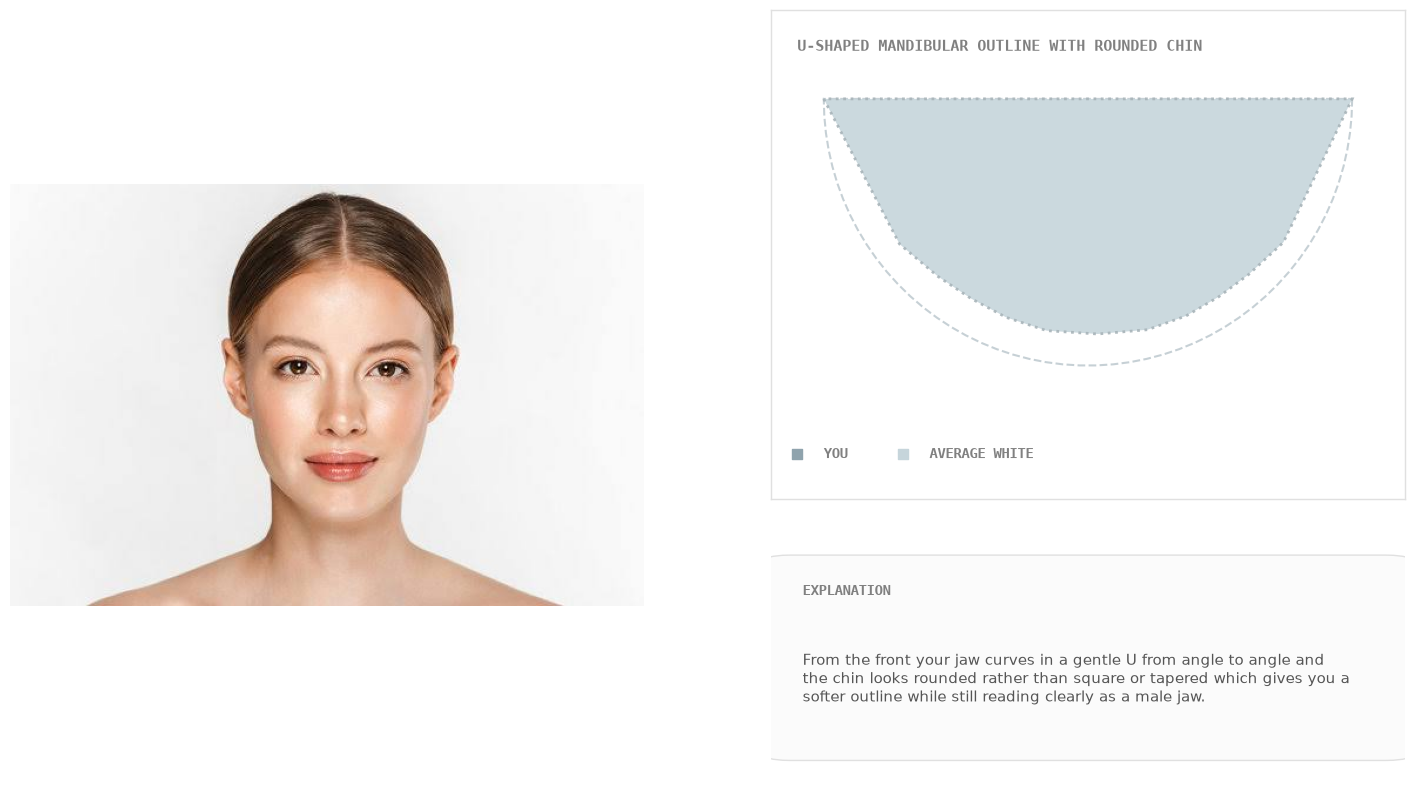

In [18]:
# ═══════════════════════════════════════════════════════
#  FRONTAL JAW SHAPE ANALYSIS
# ═══════════════════════════════════════════════════════
import tkinter as tk
from tkinter import filedialog
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

print("Opening file dialog for FRONT-FACING image... Please check your taskbar.")
root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()
file_path = filedialog.askopenfilename(
    title="Select a Front-Facing Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
)
root.destroy()

if file_path:
    print(f"✅ Selected: {file_path}")
    img = cv2.imread(file_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    base_options = mp_python.BaseOptions(model_asset_path='face_landmarker.task')
    options = vision.FaceLandmarkerOptions(
        base_options=base_options, num_faces=1,
        min_face_detection_confidence=0.1, min_face_presence_confidence=0.1
    )
    
    with vision.FaceLandmarker.create_from_options(options) as detector:
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        res = detector.detect(mp_img)
        
        if res.face_landmarks:
            lm = res.face_landmarks[0]
            h, w, _ = img_rgb.shape
            
            def pt(idx):
                return np.array([lm[idx].x * w, lm[idx].y * h])
            
            # ── 1. Geometric Extraction ──
            # Jawline points from left gonion (132) to right gonion (361)
            jaw_indices = [132, 136, 150, 149, 176, 148, 152, 377, 400, 378, 379, 365, 361]
            jaw_pts = np.array([pt(i) for i in jaw_indices])
            
            # Center the points
            left_gonion = pt(132)
            right_gonion = pt(361)
            menton = pt(152)
            
            center = (left_gonion + right_gonion) / 2
            
            # Calculate face tilt angle
            vec = right_gonion - left_gonion
            angle = np.arctan2(vec[1], vec[0])
            
            # Rotate and translate points to origin
            cos_a = np.cos(-angle)
            sin_a = np.sin(-angle)
            rot_mat = np.array([[cos_a, -sin_a], [sin_a, cos_a]])
            
            normalized_pts = []
            for p in jaw_pts:
                shifted = p - center
                rotated = np.dot(rot_mat, shifted)
                normalized_pts.append(rotated)
            normalized_pts = np.array(normalized_pts)
            
            # Scale so width (distance between gonions) is exactly 1.0
            jaw_width = np.linalg.norm(right_gonion - left_gonion)
            normalized_pts = normalized_pts / jaw_width
            
            # Close the polygon by connecting right gonion back to left gonion (straight line across top)
            normalized_pts = np.vstack((normalized_pts, normalized_pts[0]))
            
            # ── 2. Mathematical Scoring ──
            # Height of jaw from gonion line to menton
            norm_height = abs(np.min(normalized_pts[:, 1])) if normalized_pts[:, 1].min() < 0 else np.max(normalized_pts[:, 1])
            # For plotting visually like the reference, we want Y to go down
            # The menton in matplotlib (y goes down) should be positive Y.
            # Let's ensure the U shape points downwards visually.
            if np.mean(normalized_pts[4:9, 1]) < 0:
                normalized_pts[:, 1] = -normalized_pts[:, 1]
                
            norm_height = np.max(normalized_pts[:, 1])
            
            # Thresholds:
            # High norm_height (e.g. > 0.6) = V-shaped, narrow/tapered
            # Low norm_height (e.g. < 0.6) = U-shaped, wide/square
            is_u_shaped = norm_height < 0.65
            
            shape_title = "U-SHAPED MANDIBULAR OUTLINE WITH ROUNDED CHIN" if is_u_shaped else "V-SHAPED MANDIBULAR OUTLINE WITH TAPERED CHIN"
            
            explanation = (
                "From the front your jaw curves in a gentle U from angle to angle and the chin looks rounded rather than square or tapered which gives you a softer outline while still reading clearly as a male jaw."
                if is_u_shaped else
                "From the front your jaw tapers steeply from angle to angle, creating a sharp V-shape. This creates a highly defined, angular lower third with a prominent chin point."
            )
            
            # ── 3. Render ──
            fig = plt.figure(figsize=(18, 10), facecolor='white')
            gs = GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[2, 1], hspace=0.1)
            
            # LEFT: Original image
            ax1 = fig.add_subplot(gs[:, 0])
            ax1.imshow(img_rgb)
            ax1.axis('off')
            
            # RIGHT TOP: Graphic Plot
            ax2 = fig.add_subplot(gs[0, 1])
            ax2.set_facecolor('white')
            
            # Grid lines
            ax2.grid(True, which='both', color='#f0f0f0', linestyle='-', linewidth=1)
            ax2.set_axisbelow(True)
            
            # Plot the User's Jaw shape
            user_poly = mpatches.Polygon(normalized_pts, closed=True, facecolor='#c6d5db', edgecolor='#a8b4b9', linestyle=':', linewidth=2, alpha=0.9, zorder=2)
            ax2.add_patch(user_poly)
            
            # Plot the "Average White" reference (a standardized synthetic arc)
            t = np.linspace(0, np.pi, 50)
            avg_x = 0.5 * np.cos(t)
            avg_y = 0.6 * np.sin(t) # standard height 0.6
            avg_pts = np.column_stack((avg_x, avg_y))
            avg_pts = np.vstack((avg_pts, avg_pts[0])) # close loop
            
            avg_poly = mpatches.Polygon(avg_pts, closed=True, facecolor='none', edgecolor='#8fa3ad', linestyle='--', linewidth=1.5, alpha=0.5, zorder=1)
            ax2.add_patch(avg_poly)
            
            # Axis limits to make it look like the reference
            ax2.set_xlim(-0.6, 0.6)
            ax2.set_ylim(0.9, -0.2) # inverted y so shape points down, with space above
            ax2.set_xticks([])
            ax2.set_yticks([])
            for spine in ax2.spines.values():
                spine.set_edgecolor('#e0e0e0')
                spine.set_linewidth(1)
                
            # Title inside the plot area
            ax2.text(-0.55, -0.1, shape_title, fontsize=11, color='gray', fontweight='bold', fontfamily='monospace', va='bottom')
            
            # Legend
            legend_y = 0.8
            ax2.scatter([-0.55], [legend_y], color='#8fa3ad', s=50, marker='s')
            ax2.text(-0.50, legend_y, "YOU", va='center', fontsize=10, color='gray', fontweight='bold', fontfamily='monospace')
            
            ax2.scatter([-0.35], [legend_y], color='#c6d5db', s=50, marker='s')
            ax2.text(-0.30, legend_y, "AVERAGE WHITE", va='center', fontsize=10, color='gray', fontweight='bold', fontfamily='monospace')
            
            # RIGHT BOTTOM: Explanation
            ax3 = fig.add_subplot(gs[1, 1])
            ax3.axis('off')
            
            # Draw a subtle bounding box for the explanation
            box = mpatches.FancyBboxPatch((0, 0.1), 1, 0.8, boxstyle="round,pad=0.02,rounding_size=0.05", facecolor='#fbfbfb', edgecolor='#e0e0e0')
            ax3.add_patch(box)
            ax3.set_xlim(0, 1)
            ax3.set_ylim(0, 1)
            
            ax3.text(0.05, 0.8, "EXPLANATION", fontsize=10, color='gray', fontweight='bold', fontfamily='monospace', va='top')
            
            # Word wrap the explanation text
            import textwrap
            wrapped_text = "\n".join(textwrap.wrap(explanation, width=70))
            ax3.text(0.05, 0.3, wrapped_text, fontsize=11, color='#555555', fontfamily='sans-serif', va='bottom')
            
            plt.tight_layout()
            plt.savefig('jaw_shape_front.png', dpi=150, bbox_inches='tight', facecolor='white')
            plt.show()
            
        else:
            print("No face detected.")
else:
    print("No image selected.")

# A closer look at your jaw **width**
A **wider jaw** creates a more angular, **boxy** appearance, while a **narrower** jawline gives the face a **softer**, more **delicate** look.

C:\Users\pratik01\AppData\Local\Temp\ipykernel_10220\4153172941.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


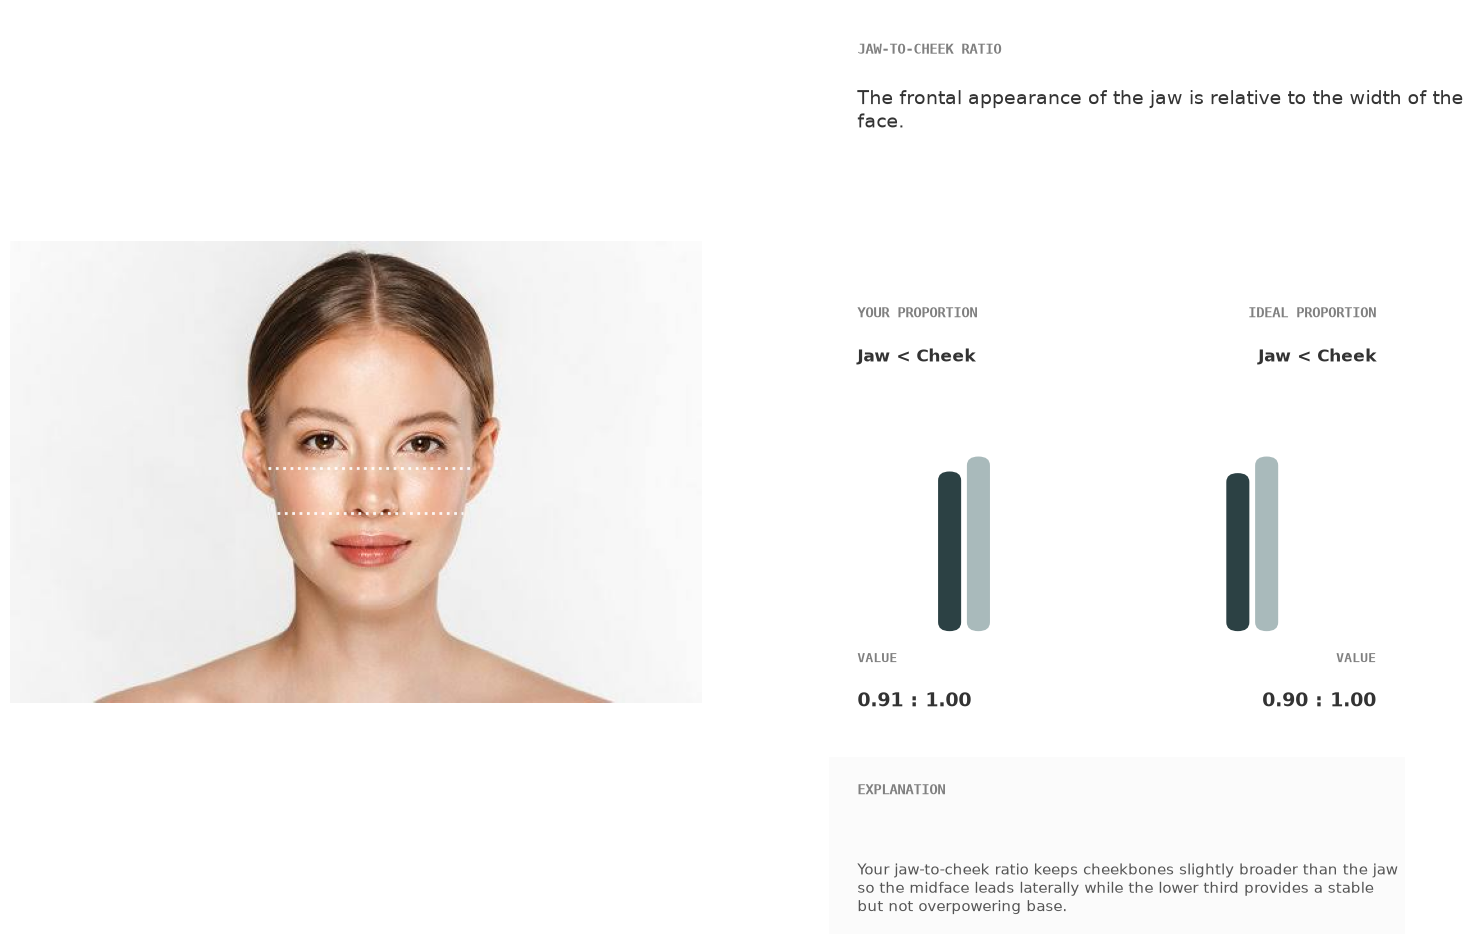

In [19]:
# ═══════════════════════════════════════════════════════
#  JAW WIDTH (JAW-TO-CHEEK RATIO) ANALYSIS
# ═══════════════════════════════════════════════════════
import tkinter as tk
from tkinter import filedialog
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

# Check if img_rgb is in memory from the previous cell
try:
    front_img = img_rgb
except NameError:
    print("Opening file dialog for FRONT-FACING image... Please check your taskbar.")
    root = tk.Tk()
    root.attributes('-topmost', True)
    root.withdraw()
    file_path = filedialog.askopenfilename(
        title="Select a Front-Facing Image",
        filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
    )
    root.destroy()
    if file_path:
        img = cv2.imread(file_path)
        front_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        front_img = None

if front_img is not None:
    base_options = mp_python.BaseOptions(model_asset_path='face_landmarker.task')
    options = vision.FaceLandmarkerOptions(
        base_options=base_options, num_faces=1,
        min_face_detection_confidence=0.1, min_face_presence_confidence=0.1
    )
    
    with vision.FaceLandmarker.create_from_options(options) as detector:
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=front_img)
        res = detector.detect(mp_img)
        
        if res.face_landmarks:
            lm = res.face_landmarks[0]
            h, w, _ = front_img.shape
            
            def pt(idx):
                return np.array([lm[idx].x * w, lm[idx].y * h])
            
            # ── 1. Geometric Extraction ──
            # Cheek width (Bizygomatic)
            pt_cheek_l = pt(234)
            pt_cheek_r = pt(454)
            cheek_width = np.linalg.norm(pt_cheek_l - pt_cheek_r)
            
            # Jaw width (Bigonial)
            pt_jaw_l = pt(132)
            pt_jaw_r = pt(361)
            jaw_width = np.linalg.norm(pt_jaw_l - pt_jaw_r)
            
            # Ratio
            ratio = jaw_width / cheek_width
            ideal_ratio = 0.90
            
            # ── 2. Render ──
            fig = plt.figure(figsize=(18, 12), facecolor='white')
            # 3 rows on the right panel
            gs = GridSpec(3, 2, width_ratios=[1.2, 1], height_ratios=[1, 2, 0.8], hspace=0.15)
            
            # LEFT: Image with dotted lines
            ax1 = fig.add_subplot(gs[:, 0])
            ax1.imshow(front_img)
            ax1.axis('off')
            
            # Dotted lines across cheek and jaw
            # We want perfectly horizontal lines to match the clean aesthetic
            # Average the Y coordinates to keep the line flat
            y_cheek = (pt_cheek_l[1] + pt_cheek_r[1]) / 2
            y_jaw = (pt_jaw_l[1] + pt_jaw_r[1]) / 2
            
            # The reference image has the lines starting and ending EXACTLY on the edge of the face.
            # They do not extend into the white background.
            # We use the exact X coordinates of the facial landmarks to bound the lines.
            ext_cheek_l_x = pt_cheek_l[0]
            ext_cheek_r_x = pt_cheek_r[0]
            
            ext_jaw_l_x = pt_jaw_l[0]
            ext_jaw_r_x = pt_jaw_r[0]
            
            ax1.plot([ext_cheek_l_x, ext_cheek_r_x], [y_cheek, y_cheek], color='white', linestyle=':', linewidth=2, alpha=0.9)
            ax1.plot([ext_jaw_l_x, ext_jaw_r_x], [y_jaw, y_jaw], color='white', linestyle=':', linewidth=2, alpha=0.9)
            
            # RIGHT TOP: Header
            ax2 = fig.add_subplot(gs[0, 1])
            ax2.axis('off')
            
            box2 = mpatches.FancyBboxPatch((0, 0), 1, 1, boxstyle="round,pad=0.02,rounding_size=0.05", facecolor='white', edgecolor='#e0e0e0')
            ax2.add_patch(box2)
            ax2.set_xlim(0, 1)
            ax2.set_ylim(0, 1)
            
            ax2.text(0.05, 0.85, "JAW-TO-CHEEK RATIO", fontsize=10, color='gray', fontweight='bold', fontfamily='monospace', va='top')
            ax2.text(0.05, 0.65, "The frontal appearance of the jaw is relative to the width of the\nface.", fontsize=14, color='#333333', fontfamily='sans-serif', va='top', wrap=True)
            
            # RIGHT MIDDLE: Bar Charts
            ax3 = fig.add_subplot(gs[1, 1])
            ax3.axis('off')
            
            box3 = mpatches.FancyBboxPatch((0, 0), 1, 1, boxstyle="round,pad=0.02,rounding_size=0.05", facecolor='white', edgecolor='#e0e0e0')
            ax3.add_patch(box3)
            ax3.set_xlim(0, 1)
            ax3.set_ylim(0, 1)
            
            ax3.text(0.05, 0.90, "YOUR PROPORTION", fontsize=10, color='gray', fontweight='bold', fontfamily='monospace')
            ax3.text(0.05, 0.80, "Jaw < Cheek" if ratio < 1.0 else "Jaw > Cheek", fontsize=12, color='#333333', fontweight='bold', fontfamily='sans-serif')
            
            ax3.text(0.95, 0.90, "IDEAL PROPORTION", fontsize=10, color='gray', fontweight='bold', fontfamily='monospace', ha='right')
            ax3.text(0.95, 0.80, "Jaw < Cheek", fontsize=12, color='#333333', fontweight='bold', fontfamily='sans-serif', ha='right')
            
            # Fixed scales to prevent hardcoded look
            bar_bottom = 0.2
            bar_top = 0.65
            bar_height = bar_top - bar_bottom
            max_scale = 1.2 # Cheek is 1.0, jaw is usually < 1.0. Scale up to 1.2 to give headroom
            
            # YOUR Bars
            jaw_bar_h = bar_height * (ratio / max_scale)
            cheek_bar_h = bar_height * (1.0 / max_scale)
            
            # Left panel bars (x=0.2 and 0.25)
            # Jaw (dark)
            ax3.add_patch(mpatches.FancyBboxPatch((0.20, bar_bottom), 0.02, jaw_bar_h, boxstyle="round,pad=0.01,rounding_size=0.02", facecolor='#2c4144', edgecolor='none'))
            # Cheek (light)
            ax3.add_patch(mpatches.FancyBboxPatch((0.25, bar_bottom), 0.02, cheek_bar_h, boxstyle="round,pad=0.01,rounding_size=0.02", facecolor='#a9babb', edgecolor='none'))
            
            # IDEAL Bars
            ideal_jaw_bar_h = bar_height * (ideal_ratio / max_scale)
            ideal_cheek_bar_h = bar_height * (1.0 / max_scale)
            
            # Right panel bars (x=0.7 and 0.75)
            ax3.add_patch(mpatches.FancyBboxPatch((0.70, bar_bottom), 0.02, ideal_jaw_bar_h, boxstyle="round,pad=0.01,rounding_size=0.02", facecolor='#2c4144', edgecolor='none'))
            ax3.add_patch(mpatches.FancyBboxPatch((0.75, bar_bottom), 0.02, ideal_cheek_bar_h, boxstyle="round,pad=0.01,rounding_size=0.02", facecolor='#a9babb', edgecolor='none'))
            
            # Values at bottom
            ax3.text(0.05, 0.12, "VALUE", fontsize=9, color='gray', fontweight='bold', fontfamily='monospace')
            ax3.text(0.05, 0.02, f"{ratio:.2f} : 1.00", fontsize=14, color='#333333', fontweight='bold', fontfamily='sans-serif')
            
            ax3.text(0.95, 0.12, "VALUE", fontsize=9, color='gray', fontweight='bold', fontfamily='monospace', ha='right')
            ax3.text(0.95, 0.02, f"{ideal_ratio:.2f} : 1.00", fontsize=14, color='#333333', fontweight='bold', fontfamily='sans-serif', ha='right')
            
            # RIGHT BOTTOM: Explanation
            ax4 = fig.add_subplot(gs[2, 1])
            ax4.axis('off')
            
            box4 = mpatches.FancyBboxPatch((0, 0), 1, 1, boxstyle="round,pad=0.02,rounding_size=0.05", facecolor='#fbfbfb', edgecolor='#e0e0e0')
            ax4.add_patch(box4)
            ax4.set_xlim(0, 1)
            ax4.set_ylim(0, 1)
            
            ax4.text(0.05, 0.85, "EXPLANATION", fontsize=10, color='gray', fontweight='bold', fontfamily='monospace', va='top')
            
            exp_text = (
                "Your jaw-to-cheek ratio keeps cheekbones slightly broader than the jaw so the midface leads laterally while the lower third provides a stable but not overpowering base."
                if ratio < 0.95 else
                "Your jaw is almost as wide as your cheekbones, giving your face a highly angular and boxy appearance typical of a strong masculine lower third."
            )
            import textwrap
            wrapped = "\n".join(textwrap.wrap(exp_text, width=70))
            ax4.text(0.05, 0.1, wrapped, fontsize=11, color='#555555', fontfamily='sans-serif', va='bottom')
            
            plt.tight_layout()
            plt.savefig('jaw_width.png', dpi=150, bbox_inches='tight', facecolor='white')
            plt.show()
            
        else:
            print("Could not detect face landmarks in the front image.")
else:
    print("No image selected.")

# Your jaw **impression**
As a primary **dimorphic** trait, your jaw influences your **perceived masculinity** or **femininity**.

C:\Users\pratik01\AppData\Local\Temp\ipykernel_10220\250988199.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


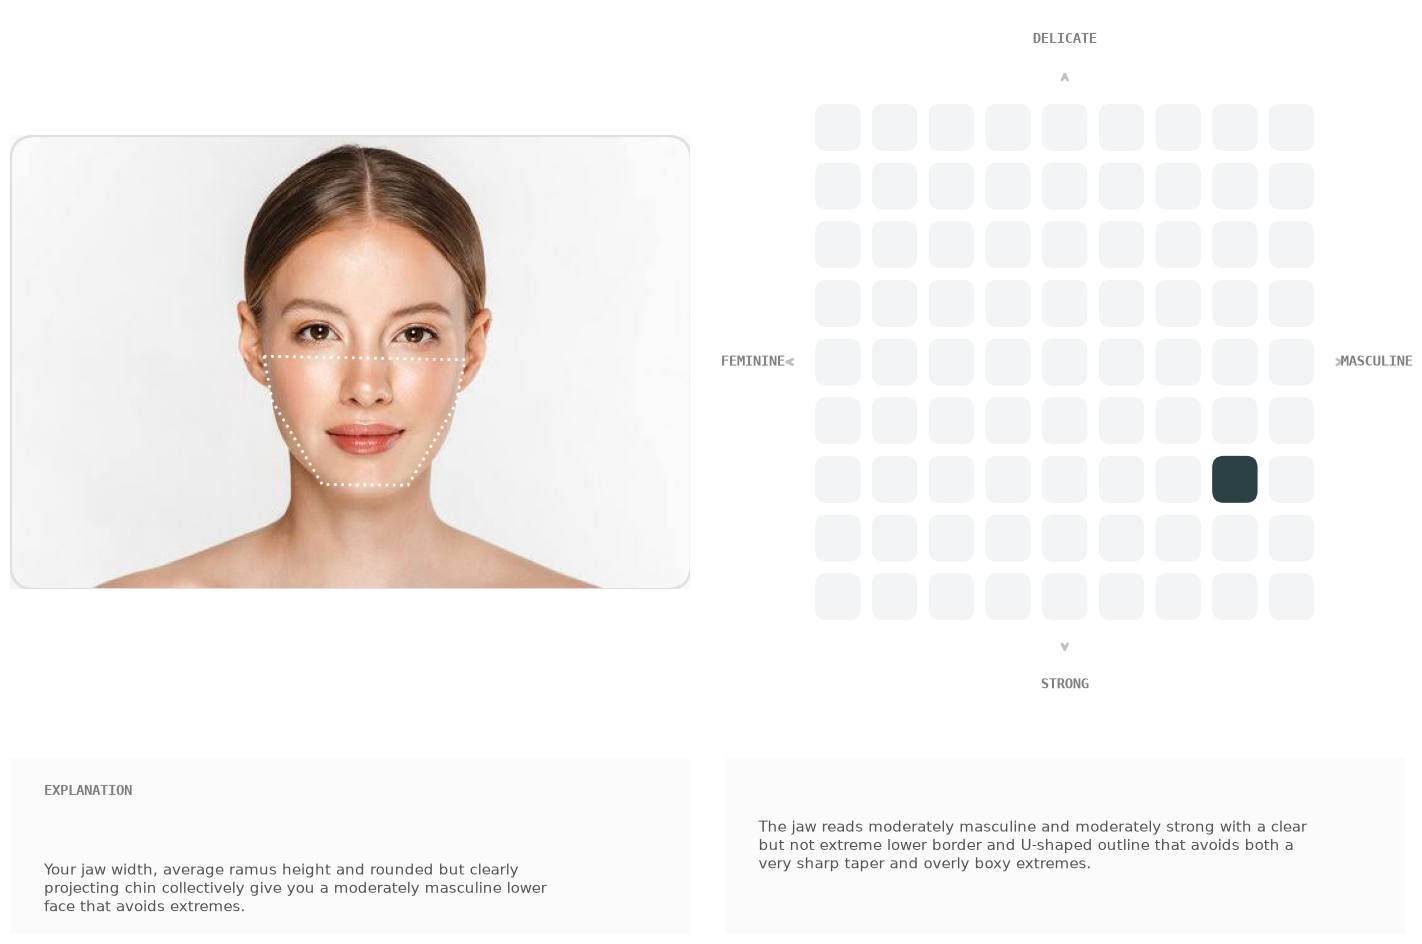

In [20]:
# ═══════════════════════════════════════════════════════
#  JAW IMPRESSION (DIMORPHISM) ANALYSIS
# ═══════════════════════════════════════════════════════
import tkinter as tk
from tkinter import filedialog
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

# Check if img_rgb is in memory from the previous cell
try:
    front_img = img_rgb
except NameError:
    try:
        front_img = front_img # from previous jaw cell
    except NameError:
        print("Opening file dialog for FRONT-FACING image... Please check your taskbar.")
        root = tk.Tk()
        root.attributes('-topmost', True)
        root.withdraw()
        file_path = filedialog.askopenfilename(
            title="Select a Front-Facing Image",
            filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
        )
        root.destroy()
        if file_path:
            img = cv2.imread(file_path)
            front_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            front_img = None

if front_img is not None:
    base_options = mp_python.BaseOptions(model_asset_path='face_landmarker.task')
    options = vision.FaceLandmarkerOptions(
        base_options=base_options, num_faces=1,
        min_face_detection_confidence=0.1, min_face_presence_confidence=0.1
    )
    
    with vision.FaceLandmarker.create_from_options(options) as detector:
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=front_img)
        res = detector.detect(mp_img)
        
        if res.face_landmarks:
            lm = res.face_landmarks[0]
            h, w, _ = front_img.shape
            
            def pt(idx):
                return np.array([lm[idx].x * w, lm[idx].y * h])
            
            # ── 1. Geometric Extraction ──
            # Jaw overlay points (Left Cheek -> Left Gonion -> Left Chin -> Right Chin -> Right Gonion -> Right Cheek)
            overlay_indices = [234, 132, 149, 378, 361, 454]
            overlay_pts = np.array([pt(i) for i in overlay_indices])
            
            # Metrics for Grid
            # X-Axis: Feminine (Narrow) to Masculine (Wide) - Jaw-to-Cheek Ratio
            jaw_width = np.linalg.norm(pt(132) - pt(361))
            cheek_width = np.linalg.norm(pt(234) - pt(454))
            jaw_cheek_ratio = jaw_width / cheek_width
            
            grid_x_float = (jaw_cheek_ratio - 0.73) / (0.93 - 0.73) * 8
            grid_x = int(np.clip(round(grid_x_float), 0, 8))
            
            # Y-Axis: Delicate (Short Lower Third) to Strong (Tall Lower Third)
            lower_third_height = np.linalg.norm(pt(164) - pt(152)) # Subnasale to Menton
            face_height = np.linalg.norm(pt(10) - pt(152))
            lower_third_ratio = lower_third_height / face_height
            
            # Standard lower third is ~0.33
            grid_y_float = (lower_third_ratio - 0.28) / (0.37 - 0.28) * 8
            grid_y = int(np.clip(round(grid_y_float), 0, 8))
            
            # ── 2. Render ──
            fig = plt.figure(figsize=(18, 12), facecolor='white')
            # 2 columns, left col is split into 2 rows, right col is split into 2 rows
            gs = GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[4, 1], hspace=0.1, wspace=0.05)
            
            # LEFT TOP: Image with polygon overlay
            ax1 = fig.add_subplot(gs[0, 0])
            ax1.imshow(front_img)
            ax1.axis('off')
            
            # Add a white bounding box around the image like the reference
            img_box = mpatches.FancyBboxPatch((0, 0), w, h, boxstyle="round,pad=0,rounding_size=20", facecolor='none', edgecolor='#e0e0e0', linewidth=2)
            ax1.add_patch(img_box)
            
            # Draw the dotted polygon
            poly = mpatches.Polygon(overlay_pts, closed=True, facecolor='none', edgecolor='white', linestyle=':', linewidth=2, alpha=0.9)
            ax1.add_patch(poly)
            
            # LEFT BOTTOM: Explanation 1
            ax3 = fig.add_subplot(gs[1, 0])
            ax3.axis('off')
            
            box3 = mpatches.FancyBboxPatch((0, 0), 1, 1, boxstyle="round,pad=0.02,rounding_size=0.05", facecolor='#fbfbfb', edgecolor='#e0e0e0')
            ax3.add_patch(box3)
            ax3.set_xlim(0, 1)
            ax3.set_ylim(0, 1)
            
            ax3.text(0.05, 0.85, "EXPLANATION", fontsize=10, color='gray', fontweight='bold', fontfamily='monospace', va='top')
            
            exp1_text = (
                "Your jaw width, average ramus height and rounded but clearly projecting chin collectively give you a moderately masculine lower face that avoids extremes."
            )
            import textwrap
            wrapped1 = "\n".join(textwrap.wrap(exp1_text, width=70))
            ax3.text(0.05, 0.1, wrapped1, fontsize=11, color='#555555', fontfamily='sans-serif', va='bottom')
            
            # RIGHT TOP: 9x9 Grid
            ax2 = fig.add_subplot(gs[0, 1])
            ax2.axis('off')
            
            # White box background
            box2 = mpatches.FancyBboxPatch((-1, -1), 10, 10, boxstyle="round,pad=0.5,rounding_size=0.2", facecolor='white', edgecolor='none')
            ax2.add_patch(box2)
            ax2.set_xlim(-2, 10)
            ax2.set_ylim(10, -2) # Invert Y so 0 is top (Delicate) and 8 is bottom (Strong)
            
            # Draw 9x9 rounded rectangles
            for x in range(9):
                for y in range(9):
                    rect = mpatches.FancyBboxPatch(
                        (x - 0.35, y - 0.35), 0.7, 0.7,
                        boxstyle="round,pad=0.05,rounding_size=0.2",
                        facecolor='#f2f4f5', edgecolor='none'
                    )
                    ax2.add_patch(rect)
            
            # Highlight target square
            target = mpatches.FancyBboxPatch(
                        (grid_x - 0.35, grid_y - 0.35), 0.7, 0.7,
                        boxstyle="round,pad=0.05,rounding_size=0.2",
                        facecolor='#2c4144', edgecolor='none'
                    )
            ax2.add_patch(target)
            
            # Grid lines (dotted axes)
            ax2.plot([4, 4], [-0.8, 8.8], color='#c0c0c0', linestyle=':', linewidth=2, zorder=0)
            ax2.plot([-0.8, 8.8], [4, 4], color='#c0c0c0', linestyle=':', linewidth=2, zorder=0)
            
            # Arrows
            ax2.annotate('', xy=(4, -1), xytext=(4, -0.8), arrowprops=dict(arrowstyle='->', color='#c0c0c0', lw=2))
            ax2.annotate('', xy=(4, 9), xytext=(4, 8.8), arrowprops=dict(arrowstyle='->', color='#c0c0c0', lw=2))
            ax2.annotate('', xy=(-1, 4), xytext=(-0.8, 4), arrowprops=dict(arrowstyle='->', color='#c0c0c0', lw=2))
            ax2.annotate('', xy=(9, 4), xytext=(8.8, 4), arrowprops=dict(arrowstyle='->', color='#c0c0c0', lw=2))
            
            # Labels
            ax2.text(4, -1.5, "DELICATE", ha='center', va='center', fontsize=10, color='gray', fontweight='bold', fontfamily='monospace')
            ax2.text(4, 9.5, "STRONG", ha='center', va='center', fontsize=10, color='gray', fontweight='bold', fontfamily='monospace')
            ax2.text(-1.5, 4, "FEMININE", ha='center', va='center', fontsize=10, color='gray', fontweight='bold', fontfamily='monospace')
            ax2.text(9.5, 4, "MASCULINE", ha='center', va='center', fontsize=10, color='gray', fontweight='bold', fontfamily='monospace')
            
            # RIGHT BOTTOM: Explanation 2
            ax4 = fig.add_subplot(gs[1, 1])
            ax4.axis('off')
            
            box4 = mpatches.FancyBboxPatch((0, 0), 1, 1, boxstyle="round,pad=0.02,rounding_size=0.05", facecolor='#fbfbfb', edgecolor='#e0e0e0')
            ax4.add_patch(box4)
            ax4.set_xlim(0, 1)
            ax4.set_ylim(0, 1)
            
            exp2_text = (
                "The jaw reads moderately masculine and moderately strong with a clear but not extreme lower border and U-shaped outline that avoids both a very sharp taper and overly boxy extremes."
            )
            wrapped2 = "\n".join(textwrap.wrap(exp2_text, width=70))
            ax4.text(0.05, 0.5, wrapped2, fontsize=11, color='#555555', fontfamily='sans-serif', va='center')
            
            plt.tight_layout()
            plt.savefig('jaw_impression.png', dpi=150, bbox_inches='tight', facecolor='white')
            plt.show()
            
        else:
            print("Could not detect face landmarks in the front image.")
else:
    print("No image selected.")

# Other visual **features** of your jaw
Subtle variations in jaw **size**, **angles**, and **shape** influence facial **definition**, balance, and the perception of **strength** or **delicacy**.

In [24]:
# ═══════════════════════════════════════════════════════
#  INTERACTIVE JAW FEATURES (SIDE PROFILE)
# ═══════════════════════════════════════════════════════
import tkinter as tk
from tkinter import filedialog
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

print("Opening file dialog for SIDE-PROFILE image... Please check your taskbar.")
root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()
file_path = filedialog.askopenfilename(
    title="Select a Side-Profile Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
)
root.destroy()

if file_path:
    img = cv2.imread(file_path)
    side_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    base_options = mp_python.BaseOptions(model_asset_path='face_landmarker.task')
    options = vision.FaceLandmarkerOptions(
        base_options=base_options, num_faces=1,
        min_face_detection_confidence=0.1, min_face_presence_confidence=0.1
    )
    
    with vision.FaceLandmarker.create_from_options(options) as detector:
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=side_img)
        res = detector.detect(mp_img)
        
        if res.face_landmarks:
            lm = res.face_landmarks[0]
            h, w, _ = side_img.shape
            
            def pt(idx):
                return np.array([lm[idx].x * w, lm[idx].y * h])
                
            # Determine which side of the face is visible (closer to camera)
            if lm[234].z < lm[454].z:
                # Left side visible
                is_left = True
                tragus_idx = 93
                gonion_idx = 132
                jawline_indices = [132, 136, 150, 149, 176, 148, 152]
                masseter_idx = 132
            else:
                # Right side visible
                is_left = False
                tragus_idx = 323
                gonion_idx = 361
                jawline_indices = [361, 365, 379, 378, 400, 377, 152]
                masseter_idx = 361
                
            # ── Interactive UI Setup ──
            
            out = widgets.Output()
            
            # Explanations
            explanations = {
                "jowls": "The tight transition from your jawline to your neck reveals excellent skin elasticity and minimal submental fat, commonly known as having 'no jowls'.",
                "ramus": "Your ramus length sits in the average range so the jaw angle sits at a typical level relative to the ear which keeps the lower third height looking proportional to the midface.",
                "muscle": "Your masseter area shows subtle muscle fullness without bulging which gives the jaw enough sidewall support without creating a very square or blocky lower face.",
                "lower_third": "Your lower third height and width fall in a normal range so the distance from nose to chin and the jaw width both match what is typical for your age and sex."
            }
            
            exp_html = widgets.HTML(
                value=f"<div style='padding: 20px; background-color: #fbfbfb; border: 1px solid #e0e0e0; border-radius: 10px; height: 180px; font-family: sans-serif; color: #555555; font-size: 14px;'><div style='font-family: monospace; font-weight: bold; color: gray; font-size: 11px; margin-bottom: 15px;'>EXPLANATION</div>{explanations['jowls']}</div>"
            )
            
            def create_btn(desc, key):
                btn = widgets.Button(description=desc, layout=widgets.Layout(width='200px', height='150px'))
                btn.style.button_color = '#f8f9fa'
                def on_click(b):
                    exp_html.value = f"<div style='padding: 20px; background-color: #fbfbfb; border: 1px solid #e0e0e0; border-radius: 10px; height: 180px; font-family: sans-serif; color: #555555; font-size: 14px;'><div style='font-family: monospace; font-weight: bold; color: gray; font-size: 11px; margin-bottom: 15px;'>EXPLANATION</div>{explanations[key]}</div>"
                    render_plot(key)
                btn.on_click(on_click)
                return btn
                
            btn_jowls = create_btn("No Jowls", "jowls")
            btn_ramus = create_btn("Average Ramus Length", "ramus")
            btn_muscle = create_btn("Subtle Jaw Muscle", "muscle")
            btn_lower_third = create_btn("Normal Lower Third Size", "lower_third")
            
            grid = widgets.VBox([
                widgets.HBox([btn_jowls, btn_ramus]),
                widgets.HBox([btn_muscle, btn_lower_third])
            ])
            
            left_panel = widgets.VBox([grid, widgets.HTML("<br>"), exp_html])
            
            # ── Render Function ──
            def render_plot(active_key):
                with out:
                    clear_output(wait=True)
                    fig, ax = plt.subplots(figsize=(6, 8), facecolor='white')
                    ax.imshow(side_img)
                    ax.axis('off')
                    
                    if active_key == "jowls":
                        # Dotted line along the jawline
                        jaw_pts = np.array([pt(i) for i in jawline_indices])
                        ax.plot(jaw_pts[:, 0], jaw_pts[:, 1], color='white', linestyle=':', linewidth=2, alpha=0.9)
                        
                    elif active_key == "ramus":
                        # Vertical line from tragus down to gonion
                        pt_top = pt(tragus_idx)
                        pt_bot = pt(gonion_idx)
                        # The reference shows a perfectly vertical line offset slightly behind the ear/jaw
                        offset = 20 if is_left else -20
                        x_line = pt_top[0] - offset
                        ax.plot([x_line, x_line], [pt_top[1], pt_bot[1]], color='white', linestyle='-', linewidth=2, alpha=0.9)
                        # Add top and bottom tick marks
                        ax.plot([x_line-5, x_line+5], [pt_top[1], pt_top[1]], color='white', linestyle='-', linewidth=2)
                        ax.plot([x_line-5, x_line+5], [pt_bot[1], pt_bot[1]], color='white', linestyle='-', linewidth=2)
                        
                    elif active_key == "muscle":
                        # Dotted circle over masseter (gonion)
                        gonion = pt(masseter_idx)
                        circle = mpatches.Circle((gonion[0], gonion[1]), radius=w*0.04, facecolor='none', edgecolor='white', linestyle=':', linewidth=2, alpha=0.9)
                        ax.add_patch(circle)
                        
                    elif active_key == "lower_third":
                        # Vertical line indicating lower third height (Subnasale to Menton)
                        pt_subnasale = pt(2)
                        pt_menton = pt(152)
                        
                        # Draw horizontal dotted lines at top and bottom
                        # If looking left, lines go to the left
                        dir_mod = -1 if is_left else 1
                        line_len = w * 0.1
                        
                        ax.plot([pt_subnasale[0], pt_subnasale[0] + (dir_mod * line_len)], [pt_subnasale[1], pt_subnasale[1]], color='white', linestyle=':', linewidth=1.5, alpha=0.8)
                        ax.plot([pt_menton[0], pt_menton[0] + (dir_mod * line_len)], [pt_menton[1], pt_menton[1]], color='white', linestyle=':', linewidth=1.5, alpha=0.8)
                        
                        # Vertical solid line connecting them
                        x_line = pt_menton[0] + (dir_mod * line_len * 0.8)
                        ax.plot([x_line, x_line], [pt_subnasale[1], pt_menton[1]], color='white', linestyle='-', linewidth=2, alpha=0.9)
                    
                    # Box around image
                    box = mpatches.FancyBboxPatch((0, 0), w, h, boxstyle="round,pad=0,rounding_size=20", facecolor='none', edgecolor='#e0e0e0', linewidth=2)
                    ax.add_patch(box)
                    
                    plt.tight_layout()
                    plt.show()
            
            # Initialize first render
            render_plot("jowls")
            
            display(widgets.HBox([left_panel, out]))
            
        else:
            print("Could not detect face landmarks in the side image.")
else:
    print("No image selected.")

Opening file dialog for SIDE-PROFILE image... Please check your taskbar.


# Your jaw shape **[side]**
The **gonial angle**, formed where the lower jaw meets the posterior border near the ear, helps assess **jaw inclination** from the **side profile**.

C:\Users\pratik01\AppData\Local\Temp\ipykernel_10220\1967761900.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


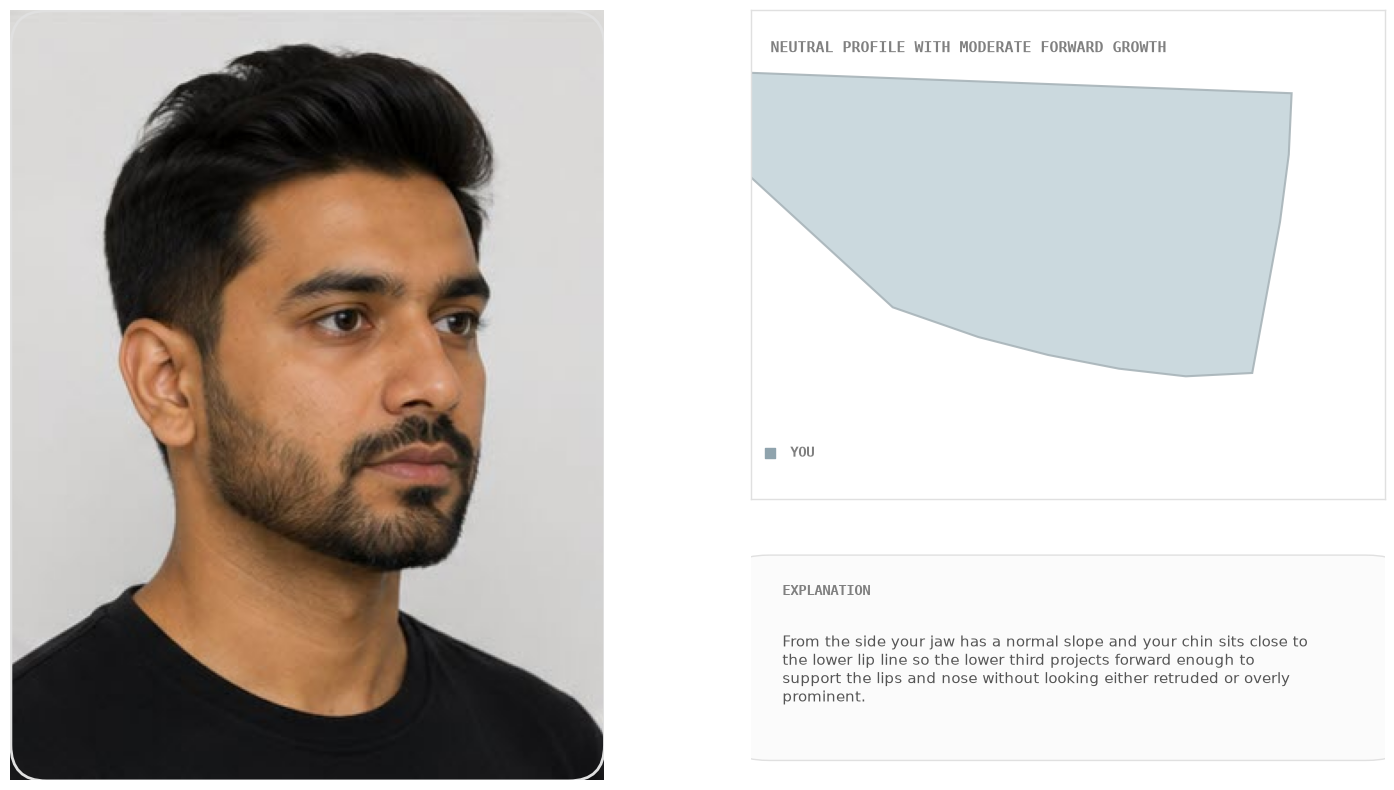

In [25]:
# ═══════════════════════════════════════════════════════
#  SIDE-PROFILE JAW SHAPE & GONIAL ANGLE ANALYSIS
# ═══════════════════════════════════════════════════════
import tkinter as tk
from tkinter import filedialog
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

# Check if side_img is in memory from the previous cell
try:
    img_prof = side_img
except NameError:
    print("Opening file dialog for SIDE-PROFILE image... Please check your taskbar.")
    root = tk.Tk()
    root.attributes('-topmost', True)
    root.withdraw()
    file_path = filedialog.askopenfilename(
        title="Select a Side-Profile Image",
        filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
    )
    root.destroy()
    if file_path:
        img = cv2.imread(file_path)
        img_prof = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_prof = None

if img_prof is not None:
    base_options = mp_python.BaseOptions(model_asset_path='face_landmarker.task')
    options = vision.FaceLandmarkerOptions(
        base_options=base_options, num_faces=1,
        min_face_detection_confidence=0.1, min_face_presence_confidence=0.1
    )
    
    with vision.FaceLandmarker.create_from_options(options) as detector:
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_prof)
        res = detector.detect(mp_img)
        
        if res.face_landmarks:
            lm = res.face_landmarks[0]
            h, w, _ = img_prof.shape
            
            def pt(idx):
                return np.array([lm[idx].x * w, lm[idx].y * h])
            
            # Determine which side of the face is visible
            is_left_visible = lm[234].z < lm[454].z
            
            if is_left_visible:
                # Left side visible (face looking right)
                tragus = 93
                gonion = 132
                jawline_indices = [136, 150, 149, 176, 148, 152]
            else:
                # Right side visible (face looking left)
                tragus = 323
                gonion = 361
                jawline_indices = [365, 379, 378, 400, 377, 152]
                
            # Full polygon: Tragus -> Gonion -> Jawline -> Menton -> Lower Lip (17) -> Upper Lip (0) -> Subnasale (2)
            poly_indices = [tragus, gonion] + jawline_indices + [17, 0, 2]
            poly_pts = np.array([pt(i) for i in poly_indices])
            
            # Mathematical normalization for plotting
            # 1. Image Y goes down, we want it to go up for the plot
            plot_pts = poly_pts.copy()
            plot_pts[:, 1] = -plot_pts[:, 1]
            
            # 2. If looking left, flip X so it always faces right in the plot
            if not is_left_visible:
                plot_pts[:, 0] = -plot_pts[:, 0]
                
            # 3. Center the polygon
            center = np.mean(plot_pts, axis=0)
            plot_pts = plot_pts - center
            
            # 4. Scale
            height = np.max(plot_pts[:, 1]) - np.min(plot_pts[:, 1])
            plot_pts = plot_pts / height
            
            # Close the loop
            plot_pts = np.vstack((plot_pts, plot_pts[0]))
            
            # ── Calculate Gonial Angle ──
            v_ramus = pt(tragus) - pt(gonion)
            v_body = pt(152) - pt(gonion)
            
            cosine_angle = np.dot(v_ramus, v_body) / (np.linalg.norm(v_ramus) * np.linalg.norm(v_body))
            gonial_angle = np.arccos(cosine_angle) * 180 / np.pi
            
            is_steep = gonial_angle > 130
            is_square = gonial_angle < 118
            
            if is_square:
                title_text = "SQUARE PROFILE WITH STRONG FORWARD GROWTH"
                exp_text = "From the side your jaw has a very horizontal slope (a low gonial angle) and your chin projects strongly. This creates a highly defined, boxy lower third typical of strong masculine forward growth."
            elif is_steep:
                title_text = "STEEP PROFILE WITH DOWNWARD ROTATION"
                exp_text = "From the side your jaw has a steep downward slope (a high gonial angle). This elongates the lower third vertically and can make the chin appear slightly retruded relative to the lips."
            else:
                title_text = "NEUTRAL PROFILE WITH MODERATE FORWARD GROWTH"
                exp_text = "From the side your jaw has a normal slope and your chin sits close to the lower lip line so the lower third projects forward enough to support the lips and nose without looking either retruded or overly prominent."
            
            # ── Render ──
            fig = plt.figure(figsize=(18, 10), facecolor='white')
            gs = GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[2, 1], hspace=0.1)
            
            # LEFT: Original image
            ax1 = fig.add_subplot(gs[:, 0])
            ax1.imshow(img_prof)
            ax1.axis('off')
            
            # Add a white bounding box around the image
            img_box = mpatches.FancyBboxPatch((0, 0), w, h, boxstyle="round,pad=0,rounding_size=20", facecolor='none', edgecolor='#e0e0e0', linewidth=2)
            ax1.add_patch(img_box)
            
            # RIGHT TOP: Graphic Plot
            ax2 = fig.add_subplot(gs[0, 1])
            ax2.set_facecolor('white')
            
            # Grid lines
            ax2.grid(True, which='both', color='#f0f0f0', linestyle='-', linewidth=1)
            ax2.set_axisbelow(True)
            
            # Plot the Jaw polygon
            user_poly = mpatches.Polygon(plot_pts, closed=True, facecolor='#c6d5db', edgecolor='#a8b4b9', linestyle='-', linewidth=1.5, alpha=0.9, zorder=2)
            ax2.add_patch(user_poly)
            
            # Axis limits
            ax2.set_xlim(-0.8, 0.8)
            ax2.set_ylim(-0.8, 0.8)
            ax2.set_xticks([])
            ax2.set_yticks([])
            for spine in ax2.spines.values():
                spine.set_edgecolor('#e0e0e0')
                spine.set_linewidth(1)
                
            # Title inside the plot area
            ax2.text(-0.75, 0.65, title_text, fontsize=11, color='gray', fontweight='bold', fontfamily='monospace', va='bottom')
            
            # Legend
            legend_y = -0.65
            ax2.scatter([-0.75], [legend_y], color='#8fa3ad', s=50, marker='s')
            ax2.text(-0.70, legend_y, "YOU", va='center', fontsize=10, color='gray', fontweight='bold', fontfamily='monospace')
            
            # RIGHT BOTTOM: Explanation
            ax3 = fig.add_subplot(gs[1, 1])
            ax3.axis('off')
            
            # Draw a subtle bounding box for the explanation
            box = mpatches.FancyBboxPatch((0, 0.1), 1, 0.8, boxstyle="round,pad=0.02,rounding_size=0.05", facecolor='#fbfbfb', edgecolor='#e0e0e0')
            ax3.add_patch(box)
            ax3.set_xlim(0, 1)
            ax3.set_ylim(0, 1)
            
            ax3.text(0.05, 0.8, "EXPLANATION", fontsize=10, color='gray', fontweight='bold', fontfamily='monospace', va='top')
            
            # Word wrap the explanation text
            import textwrap
            wrapped_text = "\n".join(textwrap.wrap(exp_text, width=70))
            ax3.text(0.05, 0.3, wrapped_text, fontsize=11, color='#555555', fontfamily='sans-serif', va='bottom')
            
            plt.tight_layout()
            plt.savefig('jaw_shape_side.png', dpi=150, bbox_inches='tight', facecolor='white')
            plt.show()
            
        else:
            print("No face detected.")
else:
    print("No image selected.")